# Detecção de Objetos com YOLOS-Small (Versão Corrigida)

Este notebook utiliza o modelo **hustvl/yolos-small** do Hugging Face. 
A lógica foi ajustada para utilizar corretamente os `labels` extraídos do pós-processamento, corrigindo problemas de mapeamento de scores/classes.

In [1]:
from transformers import YolosImageProcessor, YolosForObjectDetection
from PIL import Image
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import glob
import os

model_name = "hustvl/yolos-small"
processor = YolosImageProcessor.from_pretrained(model_name)
model = YolosForObjectDetection.from_pretrained(model_name)

print(f"Modelo {model_name} carregado com sucesso!")


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Modelo hustvl/yolos-small carregado com sucesso!


In [2]:

COLORS = ["#ff0000", "#00ff00", "#0000ff", "#ffff00", "#ff00ff", "#00ffff"]

def plot_results(pil_img, scores, labels, boxes):
    plt.figure(figsize=(12, 8))
    plt.imshow(pil_img)
    ax = plt.gca()

    for score, label, (xmin, ymin, xmax, ymax), c in zip(scores, labels, boxes.tolist(), COLORS * 100):
        ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, fill=False, color=c, linewidth=3))

        label_name = model.config.id2label[label.item()]
        text = f'{label_name}: {score:.2f}'

        ax.text(xmin, ymin, text, fontsize=12, bbox=dict(facecolor=c, alpha=0.5))

    plt.axis('off')
    plt.show()

def detectar_objetos(path_imagem, threshold=0.7):
    image = Image.open(path_imagem).convert("RGB")

    inputs = processor(images=image, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)

    target_sizes = torch.tensor([image.size[::-1]])
    results = processor.post_process_object_detection(outputs, threshold=threshold, target_sizes=target_sizes)[0]

    print(f"\nImagem: {os.path.basename(path_imagem)}")
    if len(results["scores"]) > 0:

        plot_results(image, results["scores"], results["labels"], results["boxes"])
    else:
        print(f"Nenhum objeto detectado com threshold {threshold}.")



Imagem: caoegato.jpg


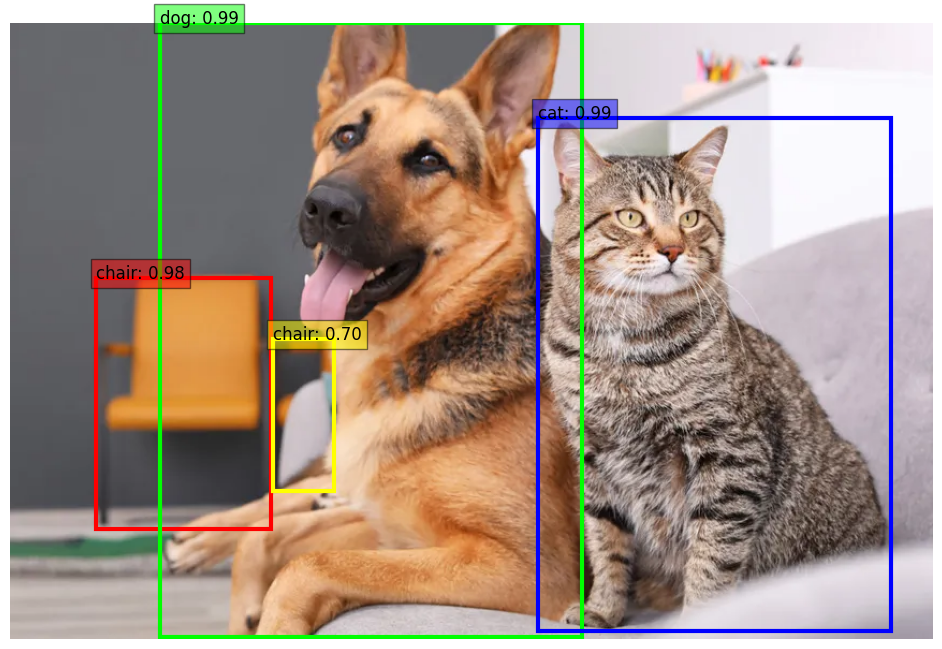


Imagem: passaro.jpg


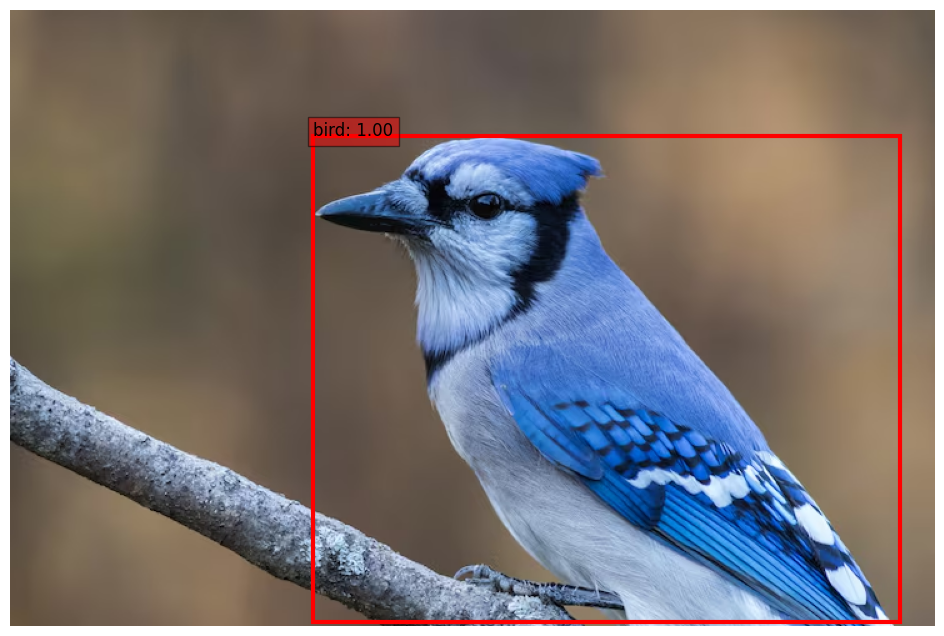


Imagem: pizza.jpg


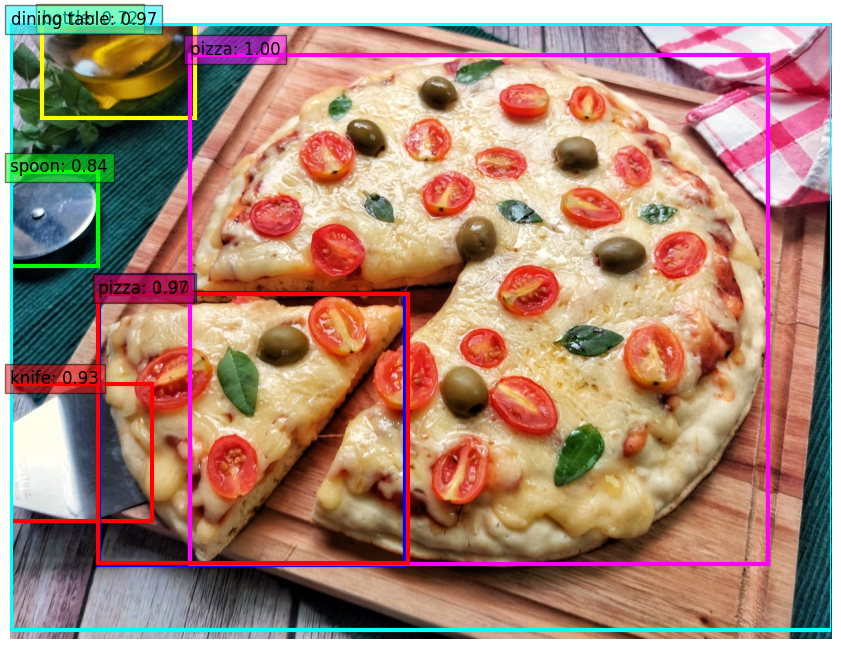

In [5]:

imagens = glob.glob("../assets/*jpg")

if not imagens:
    print("Nenhuma imagem encontrada na pasta 'imagens'.")
else:
    for img_path in imagens:

        detectar_objetos(img_path, threshold=0.7)
